<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day_12_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

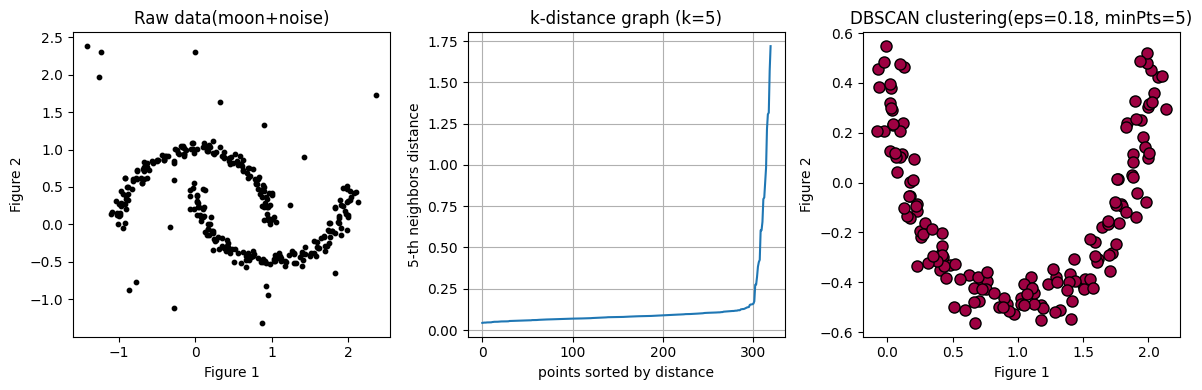

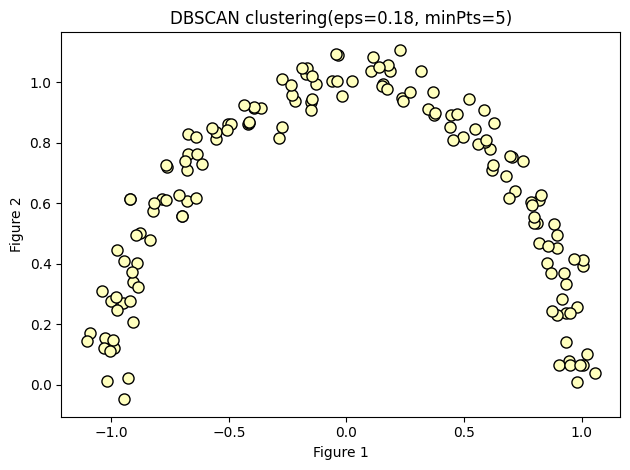

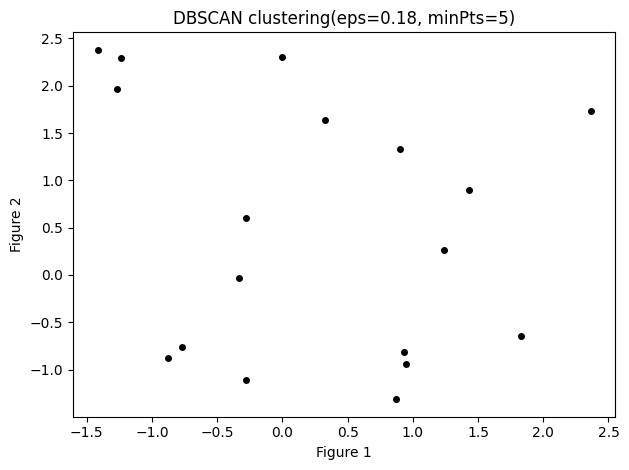

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

#Generating a non blob sataset: two interleaving half circle+noise
X,_ = make_moons(n_samples=300, noise=0.05,random_state=42)

#Add some random noise points to simulate outliers
np.random.seed(42)
noise = np.random.uniform(low=-1.5,high=2.5,size=(20,2))
X_noisy = np.vstack([X,noise])

#Visualize the raw data
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(X_noisy[:,0],X_noisy[:,1],s=10,c='k')
plt.title("Raw data(moon+noise)")
plt.xlabel("Figure 1")
plt.ylabel("Figure 2")

#use k- distance graph to estimata a good eps value
minPts = 5  #typical choice , at least dimensionality +1
neigh = NearestNeighbors(n_neighbors = minPts)
nbrs = neigh.fit(X_noisy)
distance, indices = nbrs.kneighbors(X_noisy)

#SOrt the k-th neighbors distance ( the largest distance among the minPts neighbors)
k_dist = np.sort(distance[:,minPts-1])# column index minPts -1 gives the distance to the minPts-th neighbors

plt.subplot(1,3,2)
plt.plot(k_dist)
plt.title(f'k-distance graph (k={minPts})')
plt.xlabel("points sorted by distance")
plt.ylabel(f"{minPts}-th neighbors distance")
plt.grid(True)
#An "elbow " around 0.15-0.2 is visible - we'll pick eps= 0.18

#Apply DBSCAN with the chosen eps and minPts
eps_estimate =0.18
db= DBSCAN(eps=eps_estimate, min_samples= minPts)
labels = db.fit_predict(X_noisy)

#plot the clustering result
plt.subplot(1,3,3)
#separate noise (label=-1) from cluster points
core_samples_mask = np.zeros_like(labels,dtype=bool)
core_samples_mask[db.core_sample_indices_] =True
unique_labels = set(labels)

#use a colormap
colors =[plt.cm.Spectral(each) for each in np.linspace(0,1,len(unique_labels))]
for k, col in zip (unique_labels,colors):
  if k ==-1:
    #Black used for noise
    col =[0,0,0,1]
  class_member_mask = (labels==k)

  #plot core points
  xy = X_noisy[class_member_mask & core_samples_mask]
  plt.plot(xy[:,0],xy[:,1],'o',markerfacecolor=tuple(col), markeredgecolor='k',markersize=8)

  #plot border points
  xy = X_noisy[class_member_mask & ~core_samples_mask]
  plt.plot(xy[:,0],xy[:,1],'o',markerfacecolor=tuple(col),markeredgecolor='k', markersize=4)

  plt.title(f'DBSCAN clustering(eps={eps_estimate}, minPts={minPts})')
  plt.xlabel("Figure 1")
  plt.ylabel("Figure 2")

  plt.tight_layout()
  plt.show()








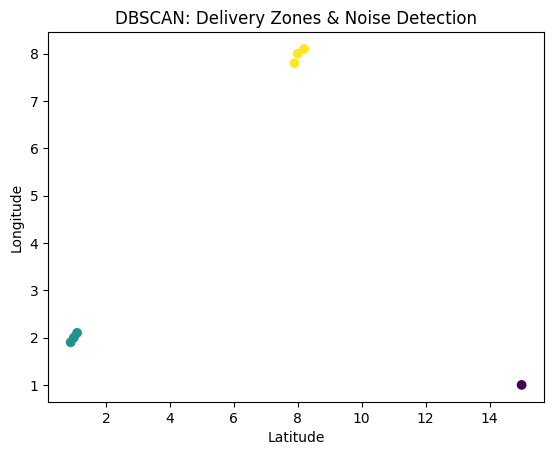

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

#Simulated GPS coordinates
X = np.array([
    [1,2],[1.1,2.1],[0.9,1.9],
    [8,8],[8.2,8.1],[7.9,7.8],
    [15,1] #noise point
])

dbscan = DBSCAN(eps=0.5,min_samples=3)
labels = dbscan.fit_predict(X)

plt.scatter(X[:,0],X[:,1], c=labels)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("DBSCAN: Delivery Zones & Noise Detection")
plt.show()